# Classification with Tensorflow/Keras

In this notebook we will use a simple DNN for classification. We will use the vehicle emissions dataset provided by the city of Albuquerque [here](https://www.cabq.gov/abq-data/), in order to predict whether a vehicle will fail the emissions test with the goal to reduce pollution in Albuquerque. We borrow a lot from work done [here](https://github.com/Guli-Y/wimlds_emissions).

Since it is a large dataset, we have taken a subset of the data. And we'll skip the exploration part.

In [1]:
# Import all the libraries I need
import numpy as np
import pandas as pd
from termcolor import colored
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# ignore Deprecation Warning
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score

import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv("../data/vehicle_emissions.csv", index_col=0)

I0000 00:00:1789631458.642477  811815 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789631458.643273  811815 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789631459.037675  811815 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789631460.501834  811815 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789631460.502305  811815 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


**Variable Description:**

|Variable|Definition   | Key  |  Type |
|---|---|---|---|
| RESULT | Passed the test? |   0 = Yes, 1 = No | Dichotomous | 
| VIN | Vehicle Identification Number | Text | 17 Char |
| TEST_SDATE | Start of test date/time | MM/DD/YYYY HH:MM:SS | Date/Time |
| MODEL_YEAR | Vehicle Model Year |	Number | Year |
| GVWR | Gross Vehicle Weight | Number | Ratio |
| ENGINE_SIZE | Engine Size volume | Number | Ratio |
| ODOMETER | Odometer Reading, number of miles | Number | Ratio |
| MAKE | Vehicle Make | Text | Nominal |

In [2]:
df.head()

,TEST_SDATE,VIN,MODEL_YEAR,GVWR,ENGINE_SIZE,ODOMETER,RESULT,MAKE
0,2014-01-06 09:17:00,JTEHP21A470207451,2007,5360,3300,58795,0,TOYOTA
1,2014-12-05 12:29:00,JT3HN86R1Y0264434,2000,5250,3400,236529,0,TOYOTA
2,2014-12-02 11:45:00,2GTEC19TX31323349,2003,6100,5300,173509,0,GMC
3,2014-09-19 08:41:00,2C3LA53G68H231030,2008,3875,3500,57883,0,CHRYSLER
4,2014-10-20 13:28:00,1GCCS19X638205261,2003,3625,4300,198516,0,CHEVROLET


## Data Cleaning

Looking at the information about each column and the missing values shows us that we have to clean our data before we can use it for modelling.

In [3]:
# transform TEST_SDATE to datetime object
df["TEST_SDATE"] = pd.to_datetime(df["TEST_SDATE"])

We approximate vehicle age in years by subtracting the model year from the test year and adding 2 years to avoid zero-age vehicles (e.g., cars tested in their model year) before dividing mileage by age.

In [4]:
# engineering VEHICLE_AGE
df["VEHICLE_AGE"] = (
    df.TEST_SDATE.dt.year.astype("int") - df.MODEL_YEAR.astype("int") + 2
)

We clean the VIN column and fill missing or zero GVWR values, if possible otherwise drop them.

In [5]:
print(colored(f"\nRecords in input data: {df.shape[0]}", "red"))
# get median GVWR for each VIN
# clean VIN
df["VIN"] = df["VIN"].astype("string").str.strip().str.lower()
# get median GVWR
tmp = df[["VIN", "GVWR"]].groupby("VIN").agg({"GVWR": "median"})
tmp.reset_index(inplace=True)
# merge tmp with df
df = df.merge(tmp, how="left", on="VIN", suffixes=("_0", ""))
# replace 0 with np.nan
df.loc[df.GVWR == 0, "GVWR"] = np.nan
df.loc[df.GVWR_0 == 0, "GVWR_0"] = np.nan
# using GVWR_0 fill missing values in GVWR
df["GVWR"] = df.GVWR.fillna(df.GVWR_0)
# keep GVW and drop GVWR_0
df = df.drop(columns=["GVWR_0"])
# drop na in GVWR
print("\nRecords with missing GVWR:", df.GVWR.isnull().sum())
df = df[~df.GVWR.isnull()]
# drop low numbers in GVWR
df = df[df.GVWR > 1000]
print(
    colored(
        f"\nRecords after droping rows where GVWR is < 1000 or missing: {df.shape[0]}",
        "red",
    )
)


Records in input data: 164108

Records with missing GVWR: 6102



Records after droping rows where GVWR is < 1000 or missing: 157998


In order to have independent test results, only keep the first if there are multiple in 90 days.

In [6]:
# if a vehicle has multiple test records within 90 days, keep earliest record
df = df.sort_values("TEST_SDATE")
df = df.loc[~(df.groupby("VIN")["TEST_SDATE"].diff() < np.timedelta64(90, "D"))]
print(
    colored(
        f"\nRecords after keeping only the earliest test within 90 days for each vehicle: {df.shape[0]}",
        "red",
    )
)


Records after keeping only the earliest test within 90 days for each vehicle: 146078


Now we can drop the `VIN` column as it does not contain useful information.

In [7]:
df = df.drop(columns=["VIN"])

Clean the `ODOMETER` column by removing zeros and `8888888` values.

In [8]:
# drop 0s in ODOMETER and remove 8888888
print("\nRecords where ODOMETER = 0:", df[df.ODOMETER == 0].shape[0])
df = df[(df.ODOMETER != 0) & (df.ODOMETER != 8888888)]
print(
    colored(
        f"\nRecords after dropping rows where ODOMETER is 0 or 8,888,888: {df.shape[0]}",
        "red",
    )
)


Records where ODOMETER = 0: 821

Records after dropping rows where ODOMETER is 0 or 8,888,888: 145195


We calculate the miles per year.

In [9]:
# engineer MILE_YEAR from ODOMETER
df["MILE_YEAR"] = np.round(df["ODOMETER"] / df["VEHICLE_AGE"], 2)

Based on the engineered features `MILE_YEAR` and `VEHICLE_AGE` we remove clear outliers: records with over 40,000 miles per year and vehicles older than 10 years showing under 1,000 miles per year.

In [10]:
# remove the outliers
df = df[df.MILE_YEAR <= 40000]
df = df[~((df.VEHICLE_AGE > 10) & (df.MILE_YEAR < 1000))]
print(
    colored(
        f"\nRecords after dropping rows where MILE_YEAR > 40,000 or (VEHICLE_AGE > 10 and MILE_YEAR < 1,000): {df.shape[0]}",
        "red",
    )
)


Records after dropping rows where MILE_YEAR > 40,000 or (VEHICLE_AGE > 10 and MILE_YEAR < 1,000): 144368


We calculate the engine - weight ratio.

In [11]:
# engineer ENGINE_WEIGHT_RATIO
df["ENGINE_WEIGHT_RATIO"] = np.round(df["ENGINE_SIZE"] / df["GVWR"], 2)

We drop remaining nan's.

In [12]:
df = df.dropna()
df = df.reset_index(drop=True)

And select a subset of columns, which are most useful.

In [13]:
cols = [
    "MODEL_YEAR",
    "VEHICLE_AGE",
    "MILE_YEAR",
    "MAKE",
    "ENGINE_WEIGHT_RATIO",
    "RESULT",
]
df = df[cols]

To avoid an explosion of columns after one-hot encoding, we relabel any make appearing in less than 1% of cars as `other`.

In [14]:
make_threshold = 0.01
# create a make label 'other' for all makes that account for <1% of cars
value_counts_norm = df["MAKE"].value_counts(normalize=True)
to_other = value_counts_norm[value_counts_norm < make_threshold]
# print(f"\n{len(to_other)} make labels each account for less than {round((make_threshold *100), 2)}% of cars and together account for {(round(to_other.sum(), 4)) *100}% of cars")
to_keep = value_counts_norm[value_counts_norm >= make_threshold]
makes_keep = list(to_keep.index)
makes_keep.sort()
other_makes = [make for make in df["MAKE"].unique() if make not in makes_keep]
df["MAKE"] = df["MAKE"].replace(other_makes, "other")
# one-hot encode the make column
df = pd.get_dummies(df, drop_first=True, dtype=float)

We split our data into train-, validation- and test-sets.

In [15]:
# Use a utility from sklearn to split and shuffle your dataset.
train_df, test_df = train_test_split(df, test_size=0.2)
train_df, val_df = train_test_split(train_df, test_size=0.2)

# Form np arrays of labels and features.
train_labels = np.array(train_df.pop("RESULT"))
val_labels = np.array(val_df.pop("RESULT"))
test_labels = np.array(test_df.pop("RESULT"))

train_features = np.array(train_df)
val_features = np.array(val_df)
test_features = np.array(test_df)

print(f"Average class probability in training set:   {train_labels.mean():.4f}")
print(f"Average class probability in validation set: {val_labels.mean():.4f}")
print(f"Average class probability in test set:       {test_labels.mean():.4f}")

Average class probability in training set:   0.0699
Average class probability in validation set: 0.0690
Average class probability in test set:       0.0683


We see that we are dealing with a highly imbalanced data set. We will use class weights to deal with that.

Neural networks are highly sensitive to the scale of the input data, and small differences in scale can have a significant impact on the performance of the network. By properly scaling input data, we can ensure that the neural network is able to effectively learn and make accurate predictions. Therefore we add a normalizer layer which we adapt on the train set only, to avoid data leakage. 

In [16]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(train_features)

E0000 00:00:1789631461.841543  811815 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Up to this point the steps should look familiar to you. But now we will create our very simple Dense Neural Network with: 
- a normalizer layer  
- a dense layer with 4 nodes and gelu activation
- a hidden layers with 4 nodes and gelu activation  
- a dropout layer (The Dropout layer randomly sets input units to 0 with a frequency of rate at each step during training time, which helps prevent overfitting. Inputs not set to 0 are scaled up by 1/(1 - rate) such that the sum over all inputs is unchanged.)
- an output layer which is used to predict a car's test result. The output layer has a sigmoid activation function, which is used to 'squash' all our outputs to be between 0 and 1.

We then compile our NN with different hyperparameters like:

1. Optimizers:
While the architecture of the Neural Network plays an important role when extracting information from data, all (most) are being optimized through update rules based on the gradient of the loss function.
The update rules are determined by the Optimizer. The performance and update speed may heavily vary from optimizer to optimizer. The gradient tells us the update direction, but it is still unclear how big of a step we might take. Short steps keep us on track, but it might take a very long time until we reach a (local) minimum. Large steps speed up the process, but it might push us off the right direction.
Adam and RMSProp are two very popular optimizers still being used in most neural networks. Both update the variables using an exponential decaying average of the gradient and its squared. But there are more, have a [look](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers).

2. Loss
Different [loss functions](https://www.tensorflow.org/api_docs/python/tf/keras/losses)

3. Metrics

4. and so on. There are many. Have a look yourself in the [documentation](https://www.tensorflow.org/api_docs/python/tf/keras)

In [17]:
# Define a Sequential model in Keras with the following architecture:
model = tf.keras.Sequential(
    [
        normalizer,
        tf.keras.layers.Dense(4, activation="gelu"),
        tf.keras.layers.Dense(4, activation="gelu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

In [18]:
# Define an Adam optimizer with a learning rate of 0.0005, 
# compile the model using binary crossentropy loss, 
# and include precision and recall as metrics.
opt = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(
    optimizer=opt,
    loss=tf.keras.losses.BinaryCrossentropy(), # for binary classification
    metrics=[
        tf.keras.metrics.Precision(thresholds=0.5),
        tf.keras.metrics.Recall(thresholds=0.5),
    ],
)

# Build the model so the summary shows concrete input shapes
model.build((None, train_features.shape[1]))

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 25)             │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180 (724.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 51 (208.00 B)

The goal is to predict failed test results, but we don't have very many of those positive samples to work with, so we would want to have the classifier heavily weight the few examples that are available. We can do this by passing Keras weights for each class through a parameter. These will cause the model to "pay more attention" to examples from an under-represented class. Note, however, that this does not increase in any way the amount of information of your dataset. Let's see how it works out.

In [20]:
# Scaling by total/2 helps keep the loss to a similar magnitude.
# The sum of the weights of all examples stays the same.
total = len(train_labels)
pos = sum(train_labels)
neg = total - pos

weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print("Weight for class 0: {:.2f}".format(weight_for_0))
print("Weight for class 1: {:.2f}".format(weight_for_1))

Weight for class 0: 0.54
Weight for class 1: 7.15


In [21]:
training = model.fit(
    train_features,
    train_labels,
    batch_size=256,
    epochs=8,
    validation_data=(val_features, val_labels),
    verbose=1,
    class_weight=class_weight,
)

Epoch 1/8


  1/361 ━━━━━━━━━━━━━━━━━━━━ 3:10 528ms/step - loss: 0.9422 - precision: 0.0934 - recall: 0.7083

 33/361 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8656 - precision: 0.0698 - recall: 0.6825    

 67/361 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8474 - precision: 0.0687 - recall: 0.6737

104/361 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8337 - precision: 0.0692 - recall: 0.6690

...

169/361 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - loss: 0.6354 - precision: 0.1293 - recall: 0.6337

222/361 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - loss: 0.6340 - precision: 0.1288 - recall: 0.6349

274/361 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 0.6329 - precision: 0.1287 - recall: 0.6366

331/361 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 0.6319 - precision: 0.1286 - recall: 0.6383

361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6264 - precision: 0.1282 - recall: 0.6479 - val_loss: 0.6147 - val_precision: 0.1278 - val_recall: 0.6786


Let's have a look at our recall at each epoch on the train- and validation set

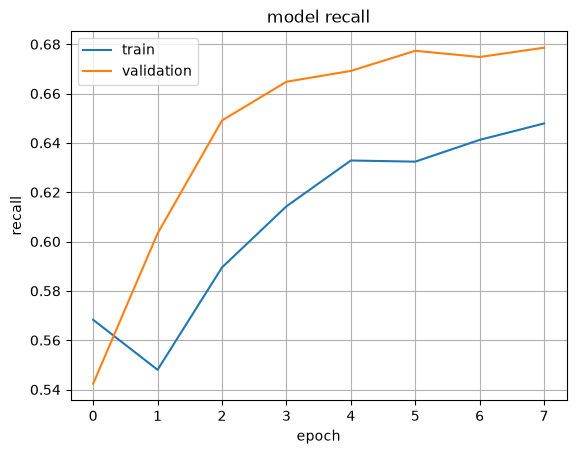

In [22]:
# summarize history for recall
plt.plot(training.history["recall"])
plt.plot(training.history["val_recall"])
plt.title("model recall")
plt.ylabel("recall")
plt.xlabel("epoch")
plt.legend(["train", "validation"], loc="upper left")
plt.grid()
plt.show()

**Exercise:** 
Plot the loss against the epochs, and discuss the result!

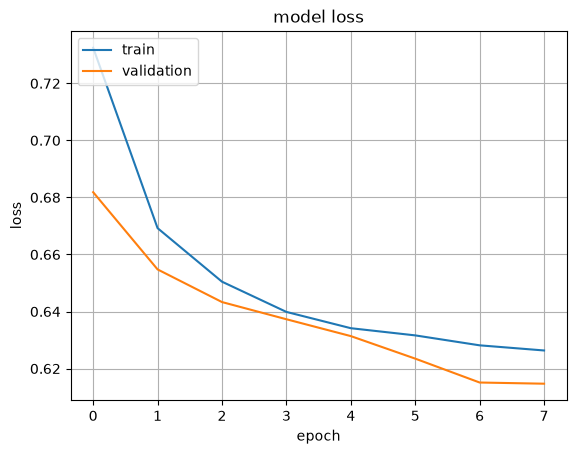

In [23]:
# summarize history for loss
plt.plot(training.history["loss"])
plt.plot(training.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "validation"], loc="upper left")
plt.grid()
plt.show()

**Discussion**

The training loss and the validation loss both fall steadily across the 8 epochs (training loss from about 0.73 to 0.63, validation loss from about 0.68 to 0.61). The two curves stay close together, and the validation loss even ends slightly below the training loss.

This tells us the model is **not overfitting**: if it were, the validation loss would flatten out or start rising while the training loss kept falling. Both curves are still trending downwards at the last epoch, which suggests the model could improve a little more if trained for a few extra epochs. (The exact numbers shift slightly from run to run because dropout and the weight initialisation are random.)

  1/903 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step

 95/903 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step

207/903 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step

319/903 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step

425/903 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step

539/903 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step

651/903 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step

759/903 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step

868/903 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step

903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step


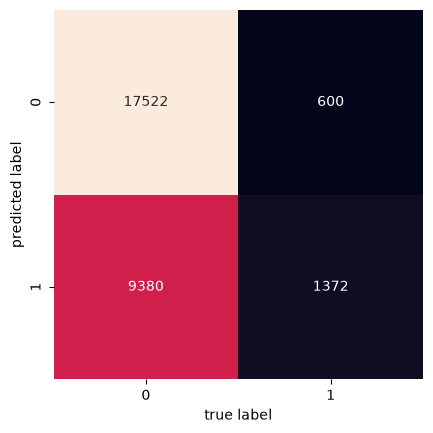

In [24]:
y_pred = model.predict(test_features)

# Plotting the confusing matrix
mat = confusion_matrix(test_labels, y_pred.round())
sns.heatmap(mat.T, square=True, annot=True, fmt="d", cbar=False)
plt.xlabel("true label")
plt.ylabel("predicted label");

In [25]:
recall = recall_score(test_labels, y_pred.round())
round(recall, 2)

0.7

The recall tells us what fraction of the vehicles that will fail the emissions test, we actually catch. To reduce pollution in Albuquerque we want this to be as high as possible without having to test as few as possible vehicles who will pass the test. So that we save money.

**Exercise:**

Change the architecture and hyperparameters of the model and see how it affects the recall. For example:
- What happens when you add layers to our model?
- What happens when you change the number of nodes?
- What when you change the batch size or the optimizer?

In [26]:
# Build a wider and deeper network, switch to a larger learning rate and a larger
# batch size, then compare the test recall to the baseline model trained above.

# keep the baseline recall (from the model above) for comparison
baseline_recall = recall_score(test_labels, y_pred.round())

# a fresh normalizer, adapted on the training features only to avoid data leakage
normalizer_2 = tf.keras.layers.Normalization(axis=-1)
normalizer_2.adapt(train_features)

# more layers and more nodes than the baseline (4, 4) network
model_2 = tf.keras.Sequential(
    [
        normalizer_2,
        tf.keras.layers.Dense(32, activation="gelu"),
        tf.keras.layers.Dense(16, activation="gelu"),
        tf.keras.layers.Dense(8, activation="gelu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

# a larger learning rate (0.001 vs 0.0005) and the same loss/metrics as before
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.Precision(thresholds=0.5),
        tf.keras.metrics.Recall(thresholds=0.5),
    ],
)

# a larger batch size (512 vs 256); keep the class weights to handle the imbalance
training_2 = model_2.fit(
    train_features,
    train_labels,
    batch_size=512,
    epochs=8,
    validation_data=(val_features, val_labels),
    verbose=1,
    class_weight=class_weight,
)

# compare test recall: baseline vs the new architecture
y_pred_2 = model_2.predict(test_features)
recall_2 = recall_score(test_labels, y_pred_2.round())

print(f"Baseline recall:  {round(baseline_recall, 2)}")
print(f"New model recall: {round(recall_2, 2)}")

Epoch 1/8


  1/181 ━━━━━━━━━━━━━━━━━━━━ 2:04 691ms/step - loss: 0.7627 - precision_1: 0.0671 - recall_1: 0.6053

 20/181 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7381 - precision_1: 0.0729 - recall_1: 0.6373    

 40/181 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7250 - precision_1: 0.0742 - recall_1: 0.6309

 62/181 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7156 - precision_1: 0.0759 - recall_1: 0.6266

...

716/903 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step

820/903 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step

903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step

903/903 ━━━━━━━━━━━━━━━━━━━━ 1s 527us/step


Baseline recall:  0.7
New model recall: 0.71


**Explanation**

Here the network was made wider and deeper (three hidden layers of 32, 16, and 8 nodes, instead of two layers of 4), the learning rate was raised from 0.0005 to 0.001, and the batch size was doubled to 512. Everything else (the class weights, the loss, and the metrics) stayed the same, so the comparison is fair.

The test recall rose from **0.70** for the baseline to **0.71** for the larger model. The extra capacity lets the network separate the two classes a little better, and on this imbalanced problem recall is the metric we care about most: we want to catch as many failing vehicles as possible.

A few things to keep in mind:

- The gain is small and the numbers move from run to run, so a single comparison is not strong evidence. Averaging several runs gives a more reliable read.
- A bigger network is more prone to overfitting. Watch the validation loss, and keep the dropout layer (and consider early stopping) to control it.
- Recall alone can be gamed by predicting "fail" for every vehicle, so always check it together with precision and the confusion matrix.